In [31]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,  cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_auc_score

In [32]:
# Download dataset
path = kagglehub.dataset_download("rabieelkharoua/predict-online-gaming-behavior-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
df

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


In [33]:
X = df[['SessionsPerWeek',
           'AchievementsUnlocked', 'PlayerLevel',
           'AvgSessionDurationMinutes']]
y = df["EngagementLevel"]

# KNN Model traning using GridsearchCV with splited data (20% test set, 80% train set)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
param_grid = {
    'n_neighbors': np.arange(1, 60, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 1, 3..., 55, 57, 59]), 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(43)


In [37]:
best_k = grid.best_params_['n_neighbors']
print(f"Optimal number of neighbors (K): {best_k}")

Optimal number of neighbors (K): 43


In [38]:
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
y_proba = best_knn.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
)

cv_scores = cross_val_score(
    best_knn,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [39]:
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nBest Parameters:")
print(grid.best_params_)
print("\n=== CROSS VALIDATION ===")
print(f"CV Accuracy Mean: {cv_scores.mean():.4f}")
print(f"CV Accuracy Std : {cv_scores.std():.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- Model Evaluation ---
Accuracy: 0.9095

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': np.int64(43), 'weights': 'distance'}

=== CROSS VALIDATION ===
CV Accuracy Mean: 0.9108
CV Accuracy Std : 0.0052

Classification Report:
              precision    recall  f1-score   support

        High       0.92      0.87      0.90      2067
         Low       0.91      0.87      0.89      2065
      Medium       0.90      0.95      0.92      3875

    accuracy                           0.91      8007
   macro avg       0.91      0.90      0.90      8007
weighted avg       0.91      0.91      0.91      8007



# Effect of K on Cross-Validated Accuracy in KNN (Across Hyperparameter Combinations)

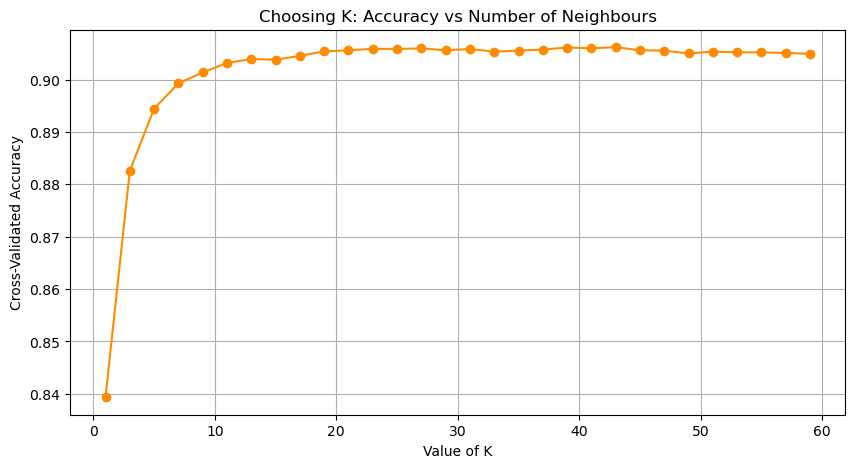

In [40]:
results = pd.DataFrame(grid.cv_results_)

# Only keep the mean score for each K.
k_curve = results.groupby('param_n_neighbors')['mean_test_score'].mean().reset_index()

# Sorting
k_curve = k_curve.sort_values('param_n_neighbors')

# Draw
plt.figure(figsize=(10, 5))

plt.plot(
    k_curve['param_n_neighbors'],
    k_curve['mean_test_score'],
    marker='o',
    color='darkorange'
)

plt.title('Choosing K: Accuracy vs Number of Neighbours')
plt.xlabel('Value of K')
plt.ylabel('Cross-Validated Accuracy')
plt.grid(True)
plt.show()

# Effect of KNN Hyperparameters (Weights & Distance Metric & K value) on Cross-Validation Accuracy

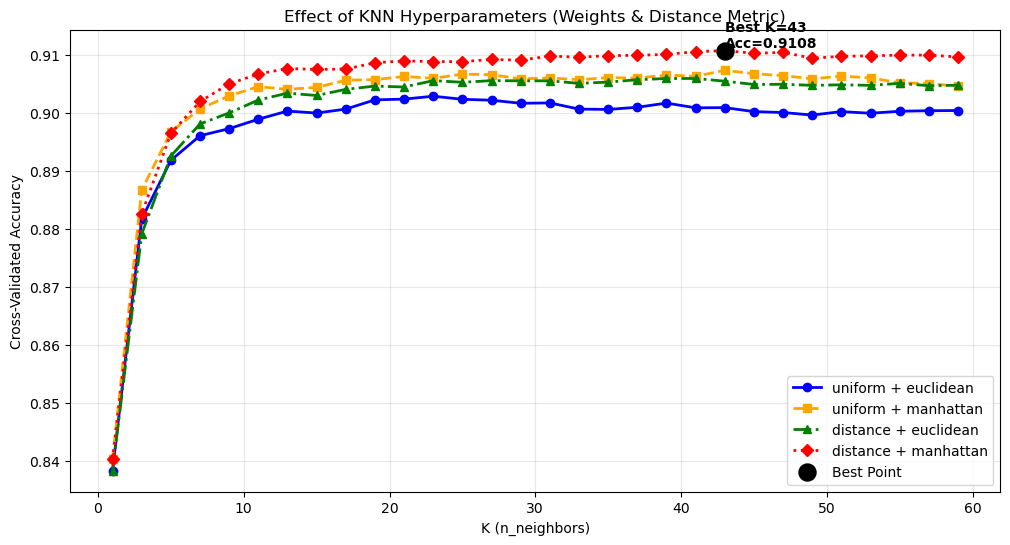

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

results = results[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']]

plt.figure(figsize=(12, 6))

# Looking design
styles = {
    ('uniform', 'euclidean'):   {'color': 'blue',   'linestyle': '-',  'marker': 'o'},
    ('uniform', 'manhattan'):   {'color': 'orange', 'linestyle': '--', 'marker': 's'},
    ('distance', 'euclidean'):  {'color': 'green',  'linestyle': '-.', 'marker': '^'},
    ('distance', 'manhattan'):  {'color': 'red',    'linestyle': ':',  'marker': 'D'}
}

best_idx = results['mean_test_score'].idxmax()
best_row = results.loc[best_idx]

for w in results['param_weights'].unique():
    for m in results['param_metric'].unique():
        
        subset = results[
            (results['param_weights'] == w) &
            (results['param_metric'] == m)
        ]
        
        k_curve = subset.groupby('param_n_neighbors')['mean_test_score'].mean().reset_index()
        k_curve = k_curve.sort_values('param_n_neighbors')
        
        style = styles[(w, m)]
        
        plt.plot(
            k_curve['param_n_neighbors'],
            k_curve['mean_test_score'],
            label=f'{w} + {m}',
            color=style['color'],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=2
        )

# ===== best point =====
plt.scatter(
    best_row['param_n_neighbors'],
    best_row['mean_test_score'],
    color='black',
    s=150,
    zorder=5,
    label='Best Point'
)

plt.text(
    best_row['param_n_neighbors'],
    best_row['mean_test_score'],
    f"Best K={best_row['param_n_neighbors']}\nAcc={best_row['mean_test_score']:.4f}",
    color='black',
    fontsize=10,
    ha='left',
    va='bottom',
    fontweight='bold'
)

plt.title('Effect of KNN Hyperparameters (Weights & Distance Metric)')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optimal KNN Hyperparameter Combination (split data version)

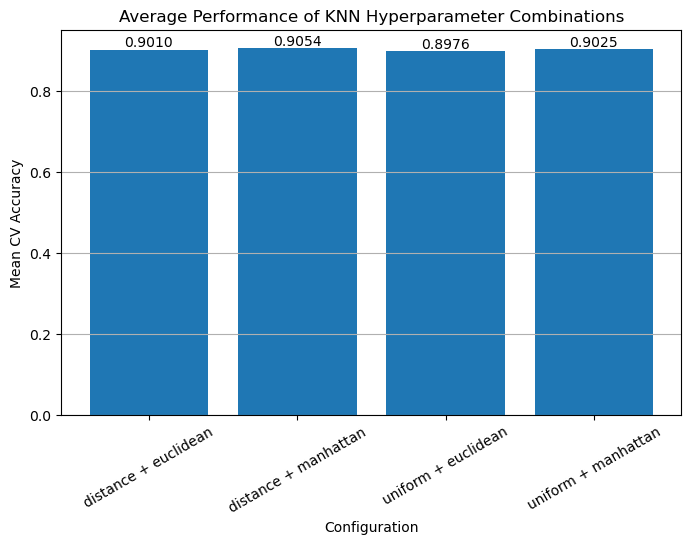

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

avg = results.groupby(['param_weights', 'param_metric'])['mean_test_score'].mean().reset_index()

labels = avg['param_weights'] + " + " + avg['param_metric']
values = avg['mean_test_score']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.title('Average Performance of KNN Hyperparameter Combinations')
plt.xlabel('Configuration')
plt.ylabel('Mean CV Accuracy')
plt.xticks(rotation=30)
plt.grid(True, axis='y')

# =====Add numerical labels=====
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.show()

# Confusion Matrix (with best parameters on 20% test set data)

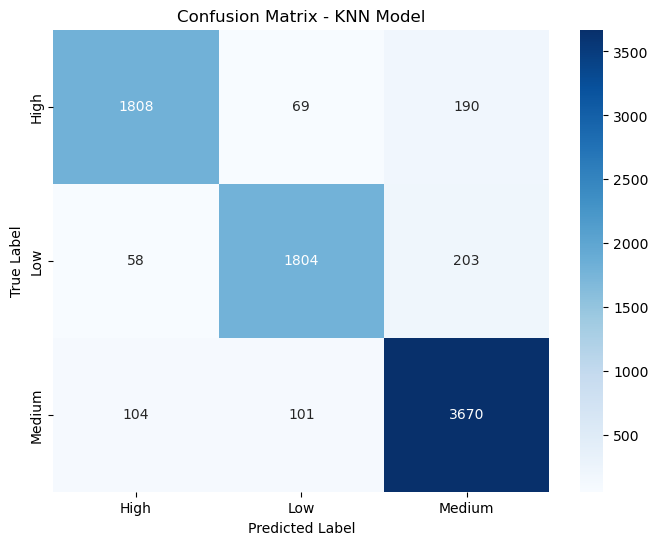

In [43]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_knn.classes_, yticklabels=best_knn.classes_)
plt.title('Confusion Matrix - KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# KNN Decision Boundary with Optimal K and Class Centers ((4D → 2D Slice) with Class Centers, other features fixed at mean)

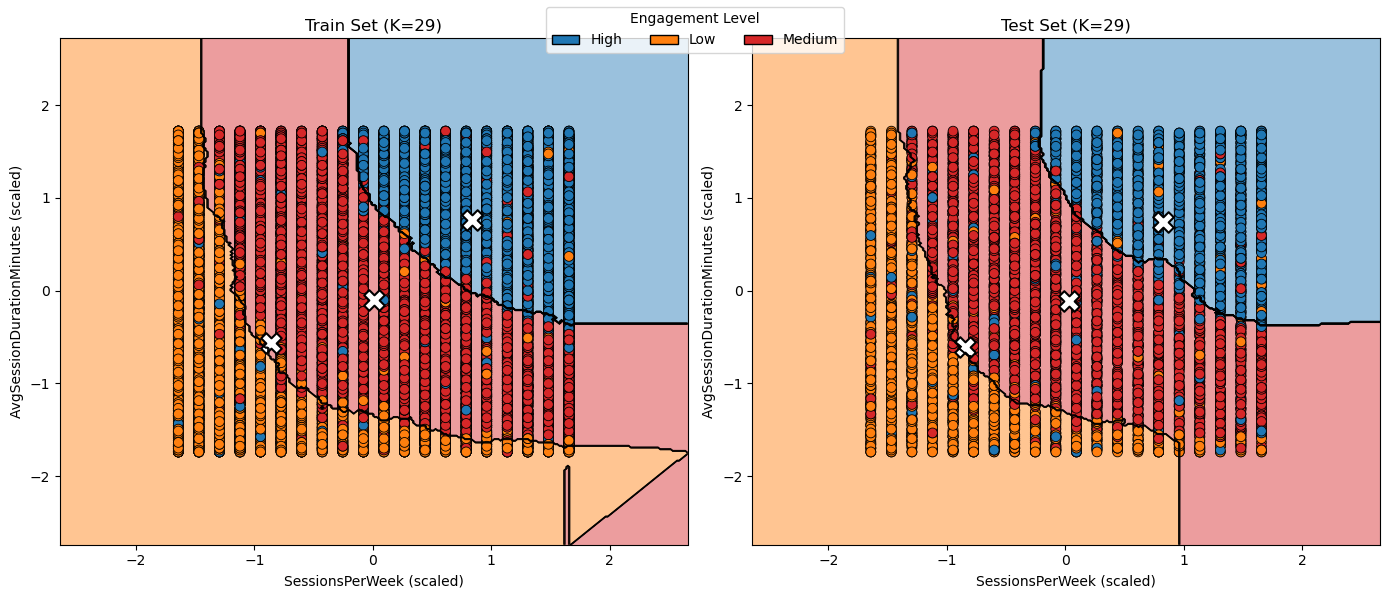

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# =========================
# Train / Test Split (IMPORTANT)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   
    stratify=y          
)

# =========================
# Label Encoding
# =========================
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
class_names = le.classes_

# =========================
# 3. Scaling (fit ONLY on train)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================
# 4. Feature selection
# =========================
feat1_name = "SessionsPerWeek"
feat2_name = "AvgSessionDurationMinutes"

feat1 = X.columns.get_loc(feat1_name)
feat2 = X.columns.get_loc(feat2_name)

# =========================
# Best K
# =========================
best_k = 29

# =========================
# 6. Color map
# =========================
cmap = ListedColormap([
    "#1f77b4",
    "#ff7f0e",
    "#d62728"
])

# =========================
# Plot function
# =========================
def plot_knn(ax, X_data, y_data, title):

    knn = KNeighborsClassifier(
        n_neighbors=best_k,
        metric='manhattan',
        weights='distance'
    )

    knn.fit(X_data, y_data)

    mean_vals = np.mean(X_data, axis=0)

    x_min, x_max = X_data[:, feat1].min() - 1, X_data[:, feat1].max() + 1
    y_min, y_max = X_data[:, feat2].min() - 1, X_data[:, feat2].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = np.tile(mean_vals, (xx.ravel().shape[0], 1))
    grid_points[:, feat1] = xx.ravel()
    grid_points[:, feat2] = yy.ravel()

    Z = knn.predict(grid_points).astype(int)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.45, cmap=cmap, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors='black', linewidths=0.6)

    ax.scatter(
        X_data[:, feat1],
        X_data[:, feat2],
        c=y_data,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.6,
        s=50
    )

    # centroids
    centroids = []
    for i in range(len(class_names)):
        class_points = X_data[y_data == i]
        centroids.append(class_points.mean(axis=0))

    centroids = np.array(centroids)

    ax.scatter(
        centroids[:, feat1],
        centroids[:, feat2],
        c="white",
        s=220,
        marker="X",
        edgecolor="black",
        linewidth=1.5
    )

    ax.set_title(title)
    ax.set_xlabel("SessionsPerWeek (scaled)")
    ax.set_ylabel("AvgSessionDurationMinutes (scaled)")

# =========================
# Plot train/test
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_knn(axes[0], X_train_scaled, y_train_encoded, f"Train Set (K={best_k})")
plot_knn(axes[1], X_test_scaled, y_test_encoded, f"Test Set (K={best_k})")

# =========================
# Legend
# =========================
fig.legend(
    handles=[
        Patch(facecolor="#1f77b4", edgecolor='black', label=class_names[0]),
        Patch(facecolor="#ff7f0e", edgecolor='black', label=class_names[1]),
        Patch(facecolor="#d62728", edgecolor='black', label=class_names[2]),
    ],
    loc="upper center",
    ncol=3,
    title="Engagement Level"
)

plt.tight_layout()
plt.show()

# PCA/LDA + KNN Decision Boundary on Test Set (Trained on Training Data Only)

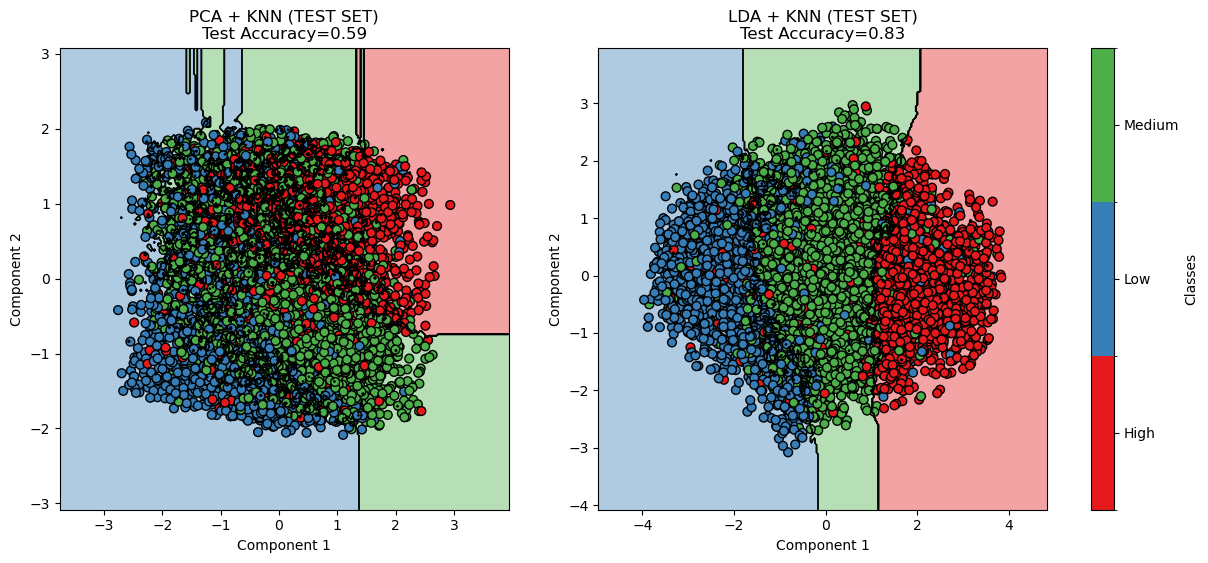

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# PCA/LDA is fitted exclusively on the training data.
# This ensures that the learned feature space is independent of the test set,
# preventing information leakage and preserving evaluation integrity.
# =========================
# encode
# =========================
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

class_names = le.classes_

# =========================
# params
# =========================
n_neighbors = 29
random_state = 42

# =========================
# models (fit ONLY on train)
# =========================
pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=random_state)
)

lda = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(n_components=2)
)

methods = [("PCA", pca), ("LDA", lda)]

# =========================
# KNN
# =========================
knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric='manhattan',
    weights='distance'
)

# =========================
# color system
# =========================
cmap = plt.cm.Set1

norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(-0.5, len(class_names) + 0.5, 1),
    ncolors=len(class_names)
)

# =========================
# figure
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, model) in enumerate(methods):

    # ===== fit ONLY on train =====
    model.fit(X_train, y_train_encoded)

    X_train_2d = model.transform(X_train)
    X_test_2d = model.transform(X_test)

    # ===== train KNN only on train =====
    knn.fit(X_train_2d, y_train_encoded)

    # ===== test accuracy =====
    acc = knn.score(X_test_2d, y_test_encoded)

    # ===== grid (based on TEST space) =====
    x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
    y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid).astype(int).reshape(xx.shape)

    ax = axes[i]

    # ===== decision boundary =====
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap, norm=norm)
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5)

    # ===== ONLY TEST POINTS =====
    ax.scatter(
        X_test_2d[:, 0],
        X_test_2d[:, 1],
        c=y_test_encoded,
        cmap=cmap,
        norm=norm,
        edgecolor='black',
        s=40
    )

    ax.set_title(f"{name} + KNN (TEST SET)\nTest Accuracy={acc:.2f}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# =========================
# colorbar
# =========================
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
    ax=axes,
    location='right',
    fraction=0.05,
    pad=0.04
)

cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)
cbar.set_label("Classes")

plt.show()

# KNN Model traning using GridsearchCV with full data (Gridsearch on full data, no test set)

In [46]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score

# ===== features =====
X = df[['SessionsPerWeek',
           'AchievementsUnlocked', 'PlayerLevel',
           'AvgSessionDurationMinutes']]

y = df["EngagementLevel"]

# =========================
# encode label
# =========================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ===== scale FULL DATA =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===== Grid Search =====
param_grid = {
    'n_neighbors': np.arange(1, 80, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=cv,
    scoring='accuracy'
)

grid.fit(X_scaled, y_encoded)

# ===== best model =====
best_k = grid.best_params_['n_neighbors']
best_knn = grid.best_estimator_

print(f"Optimal number of neighbors (K): {best_k}")
print(f"Best CV Accuracy: {grid.best_score_:.4f}")
print("Best_params:", grid.best_params_)

# ===== ROC-AUC =====
y_proba = best_knn.predict_proba(X_scaled)

roc_auc = roc_auc_score(
    y_encoded,
    y_proba,
    multi_class="ovr",
    average="macro"
)

print("\n===== ROC-AUC (KNN) =====")
print(f"ROC-AUC: {roc_auc:.4f}")

# =========================
# CV Analysis
# =========================
results = pd.DataFrame(grid.cv_results_)

best_row = results.loc[grid.best_index_]

split_scores = [
    best_row[f"split{i}_test_score"]
    for i in range(cv.n_splits)
]

print("\n--- Cross Validation Details ---")
print("CV scores:", split_scores)
print("Min:", np.min(split_scores))
print("Max:", np.max(split_scores))
print("Mean:", np.mean(split_scores))
print("Std:", best_row["std_test_score"])

# ===== 5. in-sample prediction（仅参考）=====
y_pred = best_knn.predict(X_scaled)

print("\n--- Full Data Evaluation (NOT generalization) ---")
print(f"Accuracy (training set): {accuracy_score(y_encoded, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_encoded, y_pred))

Optimal number of neighbors (K): 39
Best CV Accuracy: 0.9127
Best_params: {'metric': 'manhattan', 'n_neighbors': np.int64(39), 'weights': 'distance'}

===== ROC-AUC (KNN) =====
ROC-AUC: 1.0000

--- Cross Validation Details ---
CV scores: [np.float64(0.9159485450231047), np.float64(0.9114524790808043), np.float64(0.9117022605220432), np.float64(0.9128262770076183), np.float64(0.9114414189357981)]
Min: 0.9114414189357981
Max: 0.9159485450231047
Mean: 0.9126741961138738
Std: 0.0017147291478229196

--- Full Data Evaluation (NOT generalization) ---
Accuracy (training set): 0.9999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10336
           1       1.00      1.00      1.00     10324
           2       1.00      1.00      1.00     19374

    accuracy                           1.00     40034
   macro avg       1.00      1.00      1.00     40034
weighted avg       1.00      1.00      1.00     40034



# Effect of K on Cross-Validated Accuracy in KNN

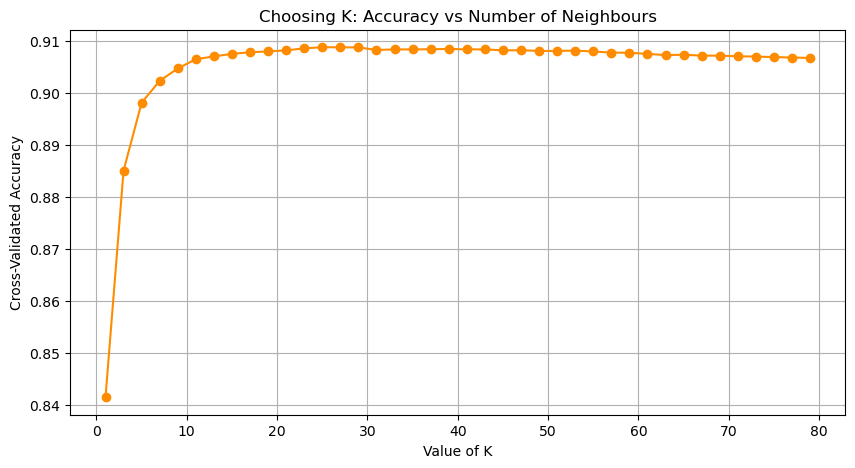

In [47]:
results = pd.DataFrame(grid.cv_results_)

# Type conversion
results['param_n_neighbors'] = results['param_n_neighbors'].astype(int)

# Only keep the mean score for each K
k_curve = results.groupby('param_n_neighbors')['mean_test_score'].mean().reset_index()

# sorting
k_curve = k_curve.sort_values('param_n_neighbors')

# draw
plt.figure(figsize=(10, 5))

plt.plot(
    k_curve['param_n_neighbors'],
    k_curve['mean_test_score'],
    marker='o',
    color='darkorange'
)

plt.title('Choosing K: Accuracy vs Number of Neighbours')
plt.xlabel('Value of K')
plt.ylabel('Cross-Validated Accuracy')
plt.grid(True)
plt.show()

# Effect of KNN Hyperparameters (K, Distance Metric, and Weighting) on Cross-Validated Accuracy

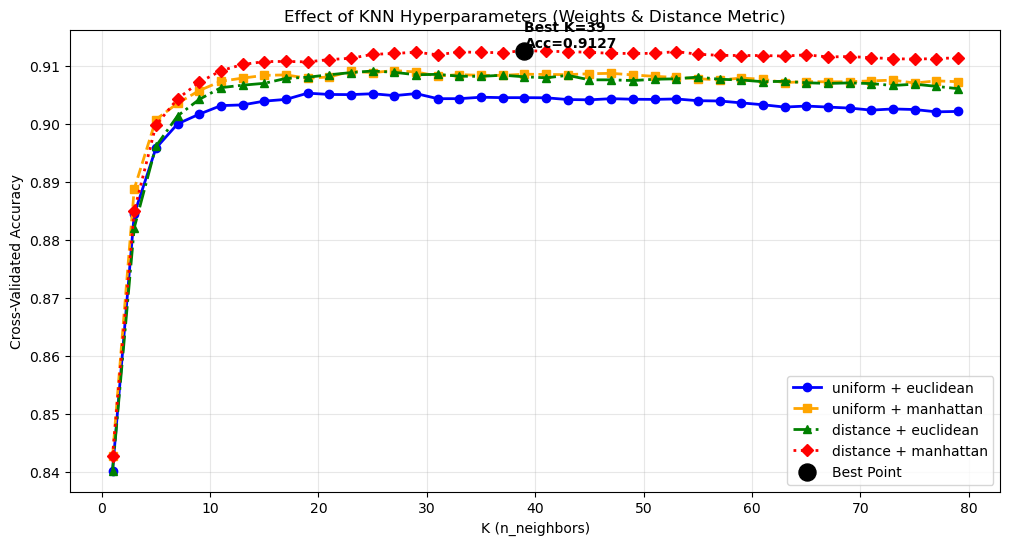

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

grid.fit(X_scaled, y)

results = pd.DataFrame(grid.cv_results_)

results = results[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']]

plt.figure(figsize=(12, 6))

# 强对比颜色 + 线型组合
styles = {
    ('uniform', 'euclidean'):   {'color': 'blue',   'linestyle': '-',  'marker': 'o'},
    ('uniform', 'manhattan'):   {'color': 'orange', 'linestyle': '--', 'marker': 's'},
    ('distance', 'euclidean'):  {'color': 'green',  'linestyle': '-.', 'marker': '^'},
    ('distance', 'manhattan'):  {'color': 'red',    'linestyle': ':',  'marker': 'D'}
}

best_idx = results['mean_test_score'].idxmax()
best_row = results.loc[best_idx]

for w in results['param_weights'].unique():
    for m in results['param_metric'].unique():
        
        subset = results[
            (results['param_weights'] == w) &
            (results['param_metric'] == m)
        ]
        
        k_curve = subset.groupby('param_n_neighbors')['mean_test_score'].mean().reset_index()
        k_curve = k_curve.sort_values('param_n_neighbors')
        
        style = styles[(w, m)]
        
        plt.plot(
            k_curve['param_n_neighbors'],
            k_curve['mean_test_score'],
            label=f'{w} + {m}',
            color=style['color'],
            linestyle=style['linestyle'],
            marker=style['marker'],
            linewidth=2
        )

# ===== best point =====
plt.scatter(
    best_row['param_n_neighbors'],
    best_row['mean_test_score'],
    color='black',
    s=150,
    zorder=5,
    label='Best Point'
)

plt.text(
    best_row['param_n_neighbors'],
    best_row['mean_test_score'],
    f"Best K={best_row['param_n_neighbors']}\nAcc={best_row['mean_test_score']:.4f}",
    color='black',
    fontsize=10,
    ha='left',
    va='bottom',
    fontweight='bold'
)

plt.title('Effect of KNN Hyperparameters (Weights & Distance Metric)')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Cross-Validated Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optimal KNN Hyperparameter Combination (full data version)

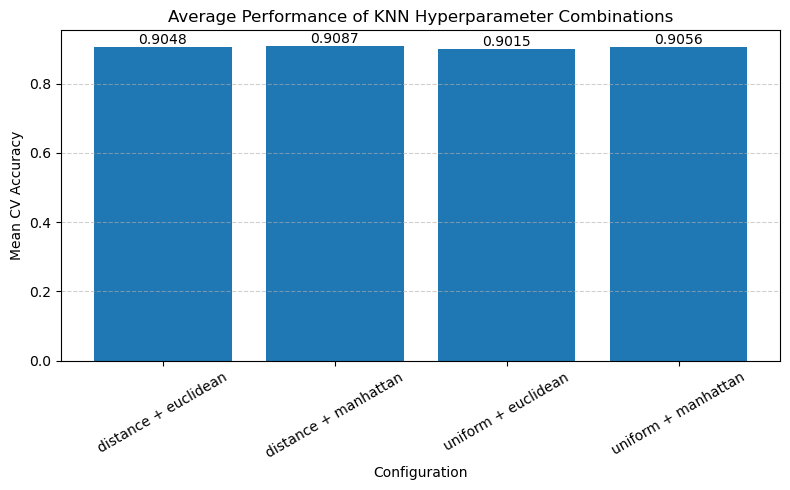

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

avg = results.groupby(
    ['param_weights', 'param_metric']
)['mean_test_score'].mean().reset_index()

labels = (
    avg['param_weights'].astype(str)
    + " + "
    + avg['param_metric'].astype(str)
)

values = avg['mean_test_score'].values

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.title('Average Performance of KNN Hyperparameter Combinations')
plt.xlabel('Configuration')
plt.ylabel('Mean CV Accuracy')
plt.xticks(rotation=30)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# ===== Add numerical labels =====
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.4f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# Confusion Matrix (on 100% data)

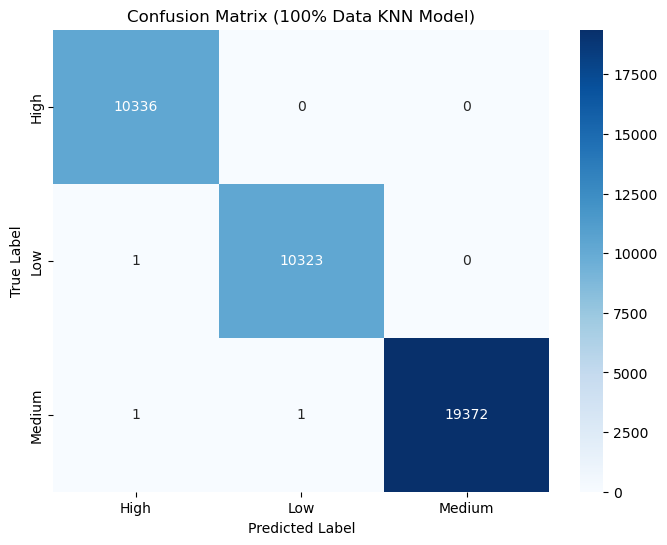

In [50]:
cm = confusion_matrix(y_encoded, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix (100% Data KNN Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

# KNN Decision Boundary with Optimal K and Class Centers ((4D → 2D Slice) with Class Centers, other features fixed at mean, on 100% data)

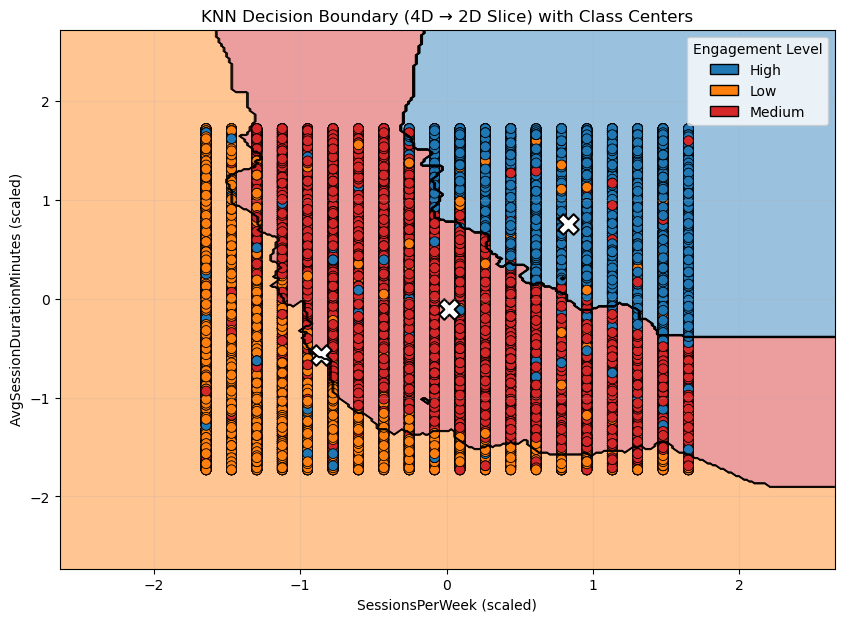

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# =========================
# features
# =========================
feat1_name = "SessionsPerWeek"
feat2_name = "AvgSessionDurationMinutes"

feat1 = X.columns.get_loc(feat1_name)
feat2 = X.columns.get_loc(feat2_name)

# =========================
# encode
# =========================
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# =========================
# scale
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# model
# =========================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_scaled, y_encoded)

# =========================
# grid
# =========================
mean_vals = np.mean(X_scaled, axis=0)

x_min, x_max = X_scaled[:, feat1].min() - 1, X_scaled[:, feat1].max() + 1
y_min, y_max = X_scaled[:, feat2].min() - 1, X_scaled[:, feat2].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.tile(mean_vals, (xx.ravel().shape[0], 1))
grid_points[:, feat1] = xx.ravel()
grid_points[:, feat2] = yy.ravel()

# =========================
# predict
# =========================
Z = knn.predict(grid_points).astype(int)
Z = Z.reshape(xx.shape)

# =========================
# colors
# =========================
cmap = ListedColormap([
    "#1f77b4",  # Low
    "#ff7f0e",  # Medium
    "#d62728"   # High
])

# =========================
# plot
# =========================
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z, alpha=0.45, cmap=cmap, levels=[-0.5, 0.5, 1.5, 2.5])
plt.contour(xx, yy, Z, colors='black', linewidths=0.6)

plt.scatter(
    X_scaled[:, feat1],
    X_scaled[:, feat2],
    c=y_encoded,
    cmap=cmap,
    edgecolor='black',
    linewidth=0.6,
    s=50
)

# =========================
# class centers
# =========================
centroids = []

for i in range(len(class_names)):
    class_points = X_scaled[y_encoded == i]
    centroids.append(class_points.mean(axis=0))

centroids = np.array(centroids)

plt.scatter(
    centroids[:, feat1],
    centroids[:, feat2],
    c="white",
    s=220,
    marker="X",
    edgecolor="black",
    linewidth=1.5
)

# =========================
# legend (FIXED - no duplicate plt.legend())
# =========================
legend_elements = [
    Patch(facecolor="#1f77b4", edgecolor='black', label=class_names[0]),
    Patch(facecolor="#ff7f0e", edgecolor='black', label=class_names[1]),
    Patch(facecolor="#d62728", edgecolor='black', label=class_names[2]),
]

plt.legend(handles=legend_elements, title="Engagement Level")

# =========================
# labels
# =========================
plt.xlabel("SessionsPerWeek (scaled)")
plt.ylabel("AvgSessionDurationMinutes (scaled)")
plt.title("KNN Decision Boundary (4D → 2D Slice) with Class Centers")

plt.grid(alpha=0.2)

plt.show()

# The number of variables with different values ​​for the same variable.

In [52]:
print(X.nunique())

SessionsPerWeek               20
AchievementsUnlocked          50
PlayerLevel                   99
AvgSessionDurationMinutes    170
dtype: int64


# PCA/LDA + KNN Classification Boundaries on Full Data (Training Visualization)

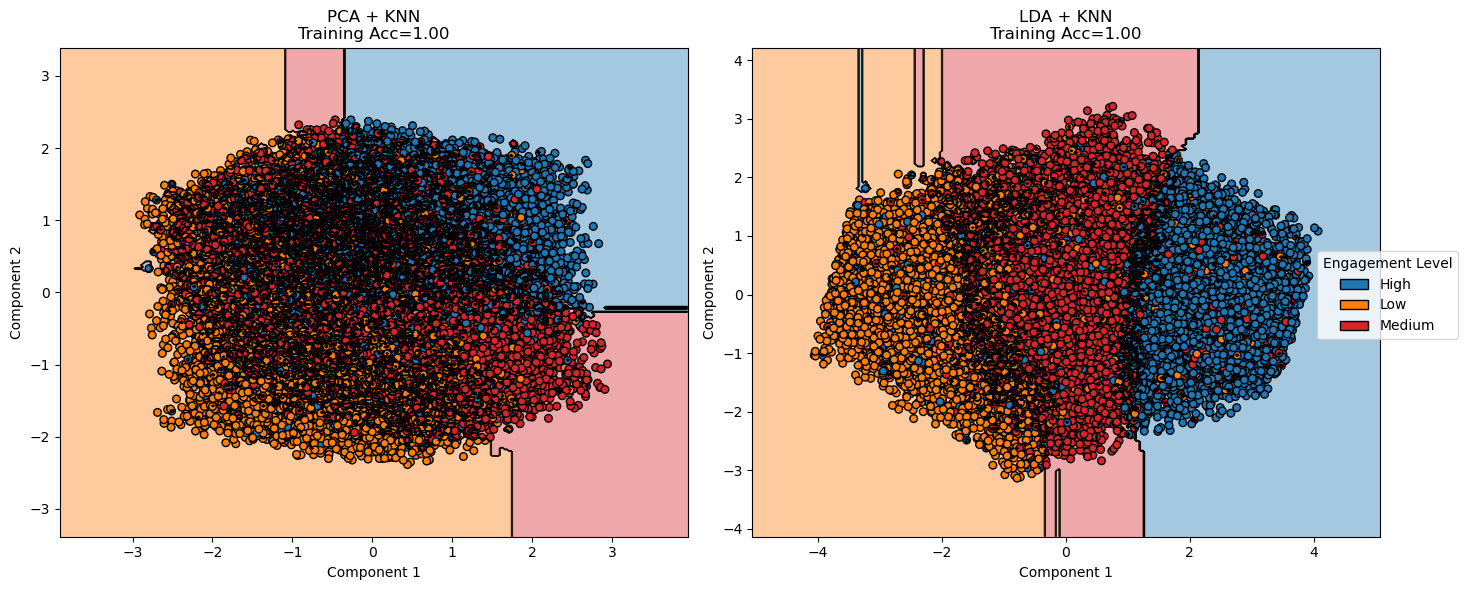

In [53]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# =========================
# encode
# =========================
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# =========================
# params
# =========================
n_neighbors = 5
random_state = 42

# =========================
# models
# =========================
pca = make_pipeline(
    StandardScaler(),
    PCA(n_components=2, random_state=random_state)
)

lda = make_pipeline(
    StandardScaler(),
    LinearDiscriminantAnalysis(n_components=2)
)

methods = [("PCA", pca), ("LDA", lda)]

# =========================
# KNN
# =========================
knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric='manhattan',
    weights='distance'
)

# =========================
# color system (统一)
# =========================
cmap = ListedColormap([
    "#1f77b4",  # Low
    "#ff7f0e",  # Medium
    "#d62728"   # High
])

# =========================
# plot
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, (name, model) in enumerate(methods):

    # ===== FULL DATA =====
    X_scaled = StandardScaler().fit_transform(X)
    model.fit(X_scaled, y_encoded)
    X_all_2d = model.transform(X_scaled)

    knn.fit(X_all_2d, y_encoded)
    acc = knn.score(X_all_2d, y_encoded)

    # ===== grid =====
    x_min, x_max = X_all_2d[:, 0].min() - 1, X_all_2d[:, 0].max() + 1
    y_min, y_max = X_all_2d[:, 1].min() - 1, X_all_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid).astype(int).reshape(xx.shape)

    ax = axes[i]

    # decision boundary
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, Z, colors='black', linewidths=0.5)

    # data points
    ax.scatter(
        X_all_2d[:, 0],
        X_all_2d[:, 1],
        c=y_encoded,
        cmap=cmap,
        edgecolor='black',
        s=30
    )

    ax.set_title(f"{name} + KNN\nTraining Acc={acc:.2f}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

# =========================
# legend（统一放一次）
# =========================
legend_elements = [
    Patch(facecolor="#1f77b4", edgecolor='black', label=class_names[0]),
    Patch(facecolor="#ff7f0e", edgecolor='black', label=class_names[1]),
    Patch(facecolor="#d62728", edgecolor='black', label=class_names[2]),
]

fig.legend(
    handles=legend_elements,
    title="Engagement Level",
    loc="right",
    bbox_to_anchor=(1.05, 0.5)
)

plt.tight_layout()
plt.show()

In [54]:
import streamlit as st
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

st.title("KNN Decision Boundary (PCA vs LDA)")

# ===== UI =====
n_neighbors = st.slider("Select K", 1, 50, 29)
method_choice = st.selectbox("Method", ["PCA", "LDA"])

# ===== encode =====
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

class_names = le.classes_

# ===== model selection =====
if method_choice == "PCA":
    model = make_pipeline(StandardScaler(), PCA(n_components=2))
else:
    model = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis(n_components=2))

# ===== transform =====
model.fit(X_train, y_train_encoded)
X_train_2d = model.transform(X_train)
X_test_2d = model.transform(X_test)

# ===== KNN =====
knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    metric='manhattan',
    weights='distance'
)
knn.fit(X_train_2d, y_train_encoded)

acc = knn.score(X_test_2d, y_test_encoded)

# ===== grid =====
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn.predict(grid).reshape(xx.shape)

# ===== plot =====
fig, ax = plt.subplots()

cmap = plt.cm.Set1
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(-0.5, len(class_names) + 0.5, 1),
    ncolors=len(class_names)
)

ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap, norm=norm)
ax.scatter(
    X_test_2d[:, 0],
    X_test_2d[:, 1],
    c=y_test_encoded,
    cmap=cmap,
    norm=norm,
    edgecolor='black'
)

ax.set_title(f"{method_choice} + KNN (Test Acc={acc:.2f})")

st.pyplot(fig)

2026-04-16 17:59:25.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.068 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.069 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.071 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 17:59:25.072 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()